# XGBoost regression
Build an XGBoost regressor model to predict 'PLACES_CANCER' using selected predictor variables in the dataset, with some categorical/ordinal variables to be one-hot encoded. Evaluate the model's performance using R-squared (R2) and Root Mean Squared Error (RMSE), visualize the actual vs. predicted values, and summarize the findings.

In [1]:
# Import necessary modules
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

In [7]:
# Read the dataset (.csv) into a Pandas dataframe
df = pd.read_csv("/content/VA_Tract_EQI_PLACES_merged_cleaned0.csv")
print("Dataset loaded successfully. First 5 rows:")
print(df.head())

Dataset loaded successfully. First 5 rows:
         tract StateAbbr     State  StateCode    County  CountyCode  \
0  51001090100        VA  Virginia         51  Accomack           1   
1  51001090200        VA  Virginia         51  Accomack           1   
2  51001090300        VA  Virginia         51  Accomack           1   
3  51001090400        VA  Virginia         51  Accomack           1   
4  51001090500        VA  Virginia         51  Accomack           1   

   CountyFIPS  RUCA_pri_cat   pop     sqmile  ...  PLACES_HIGHCHOL  \
0       51001             5  2941   7.154468  ...             41.2   
1       51001             4  6156  72.512230  ...             38.4   
2       51001             5  2335  49.587524  ...             40.3   
3       51001             5  6234  74.795433  ...             37.4   
4       51001             5  2849  25.459696  ...             37.4   

   PLACES_KIDNEY  PLACES_LPA  PLACES_MAMMOUSE  PLACES_MHLTH  PLACES_OBESITY  \
0            3.5        25.8  

In [8]:
df.columns

Index(['tract', 'StateAbbr', 'State', 'StateCode', 'County', 'CountyCode',
       'CountyFIPS', 'RUCA_pri_cat', 'pop', 'sqmile', 'pop_dens', 'facilities',
       'facilities_area', 'facilities_area_log', 'pest', 'pest_log', 'bs_25yo',
       'time2work', 'crime_index', 'crime_index_log', 'education',
       'education_area', 'education_area_log', 'food_ratio', 'nindex_open',
       'nata_sum', 'nata_sum_log', 'ozone', 'pm25', 'poverty', 'poverty_log',
       'rent_income_pct', 'selfservice', 'selfservice_log', 'unemployment',
       'unemployment_log', 'OverallEQI', 'PLACES_ACCESS2', 'PLACES_ARTHRITIS',
       'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED', 'PLACES_CANCER',
       'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
       'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD',
       'PLACES_COREM', 'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL',
       'PLACES_DIABETES', 'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA',
       'PLACES_MAMMOUSE

## 1. Prepare the Data for XGBoost
Select the outcome variable 'PLACES_CANCER' and specified predictor variables. Convert the 'RUCA_pri_cat' categorical variable into one-hot encoding. Then, define the feature set `X` and target variable `y`.


In [9]:
# Select the numerical predictor variables
predictor_variables = ['pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
                       'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
                       'poverty', 'rent_income_pct', 'selfservice', 'unemployment', 'PLACES_ACCESS2',
                       'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
                       'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
                       'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
                       'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
                       'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 'PLACES_MAMMOUSE',
                       'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP', 'PLACES_STROKE',
                       'PLACES_TEETHLOST']

X_numerical = df[predictor_variables]

# One-hot encode the 'RUCA_pri_cat' categorical variable/column
X_RUCA_onehot = pd.get_dummies(df['RUCA_pri_cat'], prefix='RUCA', drop_first=True)

# Concatenate the numerical predictors with the one-hot encoded categorical columns
X = pd.concat([X_numerical, X_RUCA_onehot], axis=1)

# Define the target variable y
y = df['PLACES_CANCER']

print("Shape of feature set X:", X.shape)
print("Shape of target variable y:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())

Shape of feature set X: (1845, 47)
Shape of target variable y: (1845,)
First 5 rows of X:
     pop_dens  facilities_area        pest  bs_25yo  time2work  crime_index  \
0  411.071808         0.000000   11.176707     27.0       17.6           56   
1   84.896019         0.082745  344.039331     24.3       19.5          244   
2   47.088455         0.040333  125.706110      6.7       19.2           81   
3   83.347336         0.000000  330.874284      8.2       23.8           75   
4  111.902359         0.039278  240.178312     17.6       17.1           60   

   education_area  food_ratio  nindex_open  nata_sum  ...  PLACES_MHLTH  \
0    4.193184e-01    0.340909    92.692253  0.988358  ...          12.5   
1    9.653544e-02    0.454545    68.456841  1.094157  ...          14.6   
2    2.016636e-02    0.285714    84.836143  1.117513  ...          16.9   
3    9.358860e-02    0.153846    65.198860  1.026764  ...          17.5   
4    3.520000e-19    0.250000    70.192398  1.095621  ...   

# 2. Data splitting
Split the dataset into training/validation and test sets, stratified by the `RUCA_pri_cat` column, to ensure a proportional representation of its categories in both sets.

### 2.1 Initial Stratified Train-Test Split
First, split the entire dataset (X, y) into a main training/validation set (80%) and a test set (20%). This split will be stratified by the 'RUCA_pri_cat' column to ensure proportional representation of its categories in both sets.

In [ ]:
# Split the data into training/validation and test sets, stratified by 'RUCA_pri_cat'
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=df['RUCA_pri_cat'], random_state=42)

print("Shape of X_train_val:", X_train_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train_val:", y_train_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_val: (1476, 47)
Shape of X_test: (369, 47)
Shape of y_train_val: (1476,)
Shape of y_test: (369,)


### 2.2 Define Stratified K-Fold (K=5) Cross-Validation
Define a 5-fold cross-validation strategy on the training/validation set, stratifying by the 'RUCA_pri_cat' column. This will generate indices for 5 distinct train-validation splits while also ensuring each fold has a similar distribution of 'RUCA_pri_cat' categories.

In [ ]:
# Convert 'RUCA_pri_cat' to integer labels for stratification
# Ensure we only get the 'RUCA_pri_cat' values corresponding to the X_train_val indices
ruca_stratify_labels_train_val = df.loc[X_train_val.index, 'RUCA_pri_cat'].astype('category').cat.codes

# Instantiate StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stratified_cv_indices = skf.split(X_train_val, ruca_stratify_labels_train_val)

print("StratifiedKFold instance created with 5 splits, shuffled, and random_state=42.")
print("RUCA stratification labels prepared for X_train_val.")

StratifiedKFold instance created with 5 splits, shuffled, and random_state=42.
RUCA stratification labels prepared for X_train_val.


## 3. Train a XGBoost Regressor with Stratified Cross-Validation and Fine-tune the Hyperparameters
Iterate through each fold generated by `StratifiedKFold`. For each fold, train an XGBoost Regressor model and fine tuen the hyperparameter grid on the training subset and evaluate its performance on the corresponding validation subset, using the performance metrics of R-squared (R2) and Root Mean Squared Error (RMSE).

Define a parameter grid that includes key XGBoost hyperparameters such as `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, and `gamma`, and use R-squared as the scoring metric. Setup and execute hyperparameter tuning with Cross-Validation for the XGBoost model using `GridSearchCV` on the `X_train_val` and `y_train_val` datasets, employing the previously defined `StratifiedKFold` (`skf`) for the stratified 5-fold cross-validation.  Afterwards, retrieve and print the best hyperparameters and the corresponding best R-squared score found by `GridSearchCV`.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [4, 6, 8],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Instantiate an XGBRegressor model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Instantiate GridSearchCV
# The 'skf' object was defined in a previous cell for stratified cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2', # target is to maximize R-squared
    cv=skf.split(X_train_val, ruca_stratify_labels_train_val), # Use the pre-defined StratifiedKFold object
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

print("Starting GridSearchCV to find the best hyperparameters...")

# Fit GridSearchCV to the training/validation data
grid_search.fit(X_train_val, y_train_val)

print("GridSearchCV complete.")

# Print the best parameters found
print("\nBest parameters found:", grid_search.best_params_)

# Print the best R-squared score found
print(f"Best R-squared from GridSearchCV: {grid_search.best_score_:.4f}")

Starting GridSearchCV to find the best hyperparameters...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
GridSearchCV complete.

Best parameters found: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Best R-squared from GridSearchCV: 0.9781


## 4. Visualize Hyperparameter Tuning Results
To visualize the impact of hyperparameter tuning, we will create heatmaps showing the R-squared scores across different combinations of n_estimators, max_depth, and learning_rate, holding other parameters at their best-found values.

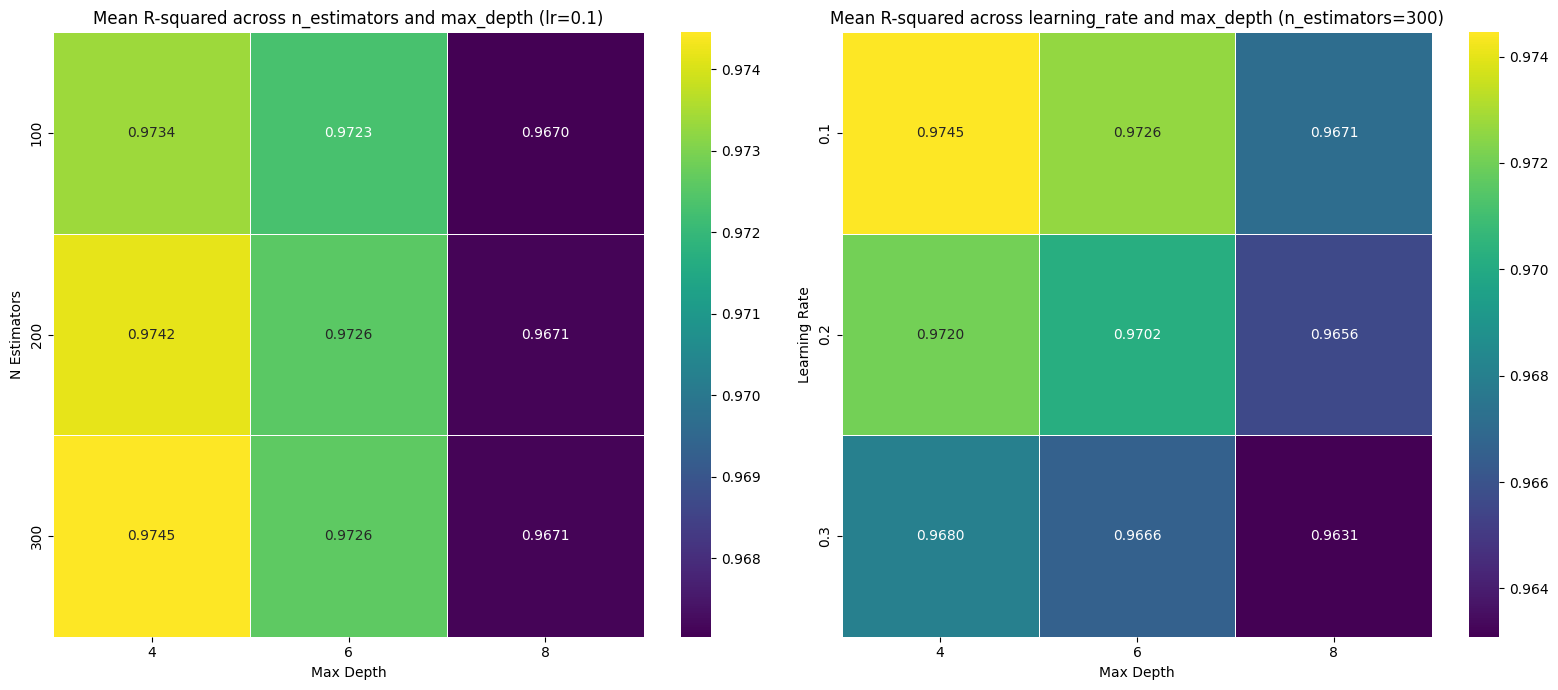

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the results of GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Create a pivot table for n_estimators and max_depth, averaging over other parameters
# Filter for best learning_rate for a clearer plot
best_lr = grid_search.best_params_['learning_rate']
results_filtered = results[results['param_learning_rate'] == best_lr]

pivot_table_r2_n_est_max_depth = results_filtered.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_max_depth'
)

# Create a pivot table for learning_rate and max_depth, averaging over other parameters
best_n_estimators = grid_search.best_params_['n_estimators']
results_filtered_n_est = results[results['param_n_estimators'] == best_n_estimators]
pivot_table_r2_lr_max_depth = results_filtered_n_est.pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)

plt.figure(figsize=(16, 7))

# Plot heatmap for n_estimators vs. max_depth
plt.subplot(1, 2, 1)
sns.heatmap(pivot_table_r2_n_est_max_depth, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title(f'Mean R-squared across n_estimators and max_depth (lr={best_lr})')
plt.xlabel('Max Depth')
plt.ylabel('N Estimators')

# Plot heatmap for learning_rate vs. max_depth
plt.subplot(1, 2, 2)
sns.heatmap(pivot_table_r2_lr_max_depth, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title(f'Mean R-squared across learning_rate and max_depth (n_estimators={best_n_estimators})')
plt.xlabel('Max Depth')
plt.ylabel('Learning Rate')

plt.tight_layout()
plt.show()

## 5. Final Model Training and Evaluation on the Unseen Test Set
After training and validating across all folds (by which we have an idea of the model's performance), train a final XGBoost model on the entire stratified training/validation set (`X_train_val`, `y_train_val`). Then, use this final model to make predictions on the initial, completely unseen stratified test set (`X_test`) and evaluate its final and unbiased performance using R2 and RMSE.

### 5.1 Train a new and final XGBoost model using the optimal hyperparameters found by GridSearchCV on the entire training/validation dataset (X_train_val, y_train_val).


In [ ]:
import numpy as np
from xgboost import XGBRegressor

# 1. Retrieve the optimal hyperparameters from grid_search.best_params_
best_params = grid_search.best_params_
print("Optimal Hyperparameters found by GridSearchCV:", best_params)

# 2. Instantiate a new XGBRegressor model with optimal hyperparameters
final_tuned_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma']
)

print("\nInstantiated final XGBoost model with optimal hyperparameters.")

# 3. Train this final model using the entire X_train_val and y_train_val datasets
print("Training final tuned XGBoost model on the entire training/validation set...")
final_tuned_xgb_model.fit(X_train_val, y_train_val)
print("Final tuned model training complete.")

Optimal Hyperparameters found by GridSearchCV: {'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}

Instantiated final XGBoost model with optimal hyperparameters.
Training final tuned XGBoost model on the entire training/validation set...
Final tuned model training complete.


### 5.2 Evaluate Tuned Model on Test Set
Use the final, optimally tuned XGBoost model to make predictions on the completely unseen test set (`X_test`). Evaluate its performance using R-squared (R2) and Root Mean Squared Error (RMSE) to obtain an unbiased estimate of the model's generalization capabilities.


In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# 1. Use the final_tuned_xgb_model to make predictions on the X_test dataset
y_pred_test_tuned = final_tuned_xgb_model.predict(X_test)

# 2. Calculate the R-squared score between y_test and y_pred_test_tuned
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)

# 3. Calculate the Root Mean Squared Error (RMSE) between y_test and y_pred_test_tuned
rmse_test_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))

# 4. Print the calculated R-squared and RMSE values for the test set
print(f"\nTest Set R-squared (final tuned model): {r2_test_tuned:.4f}")
print(f"Test Set RMSE (final tuned model): {rmse_test_tuned:.4f}")


Test Set R-squared (final tuned model): 0.9823
Test Set RMSE (final tuned model): 0.2212


## 6. Visualize Predictions
Generate a scatter plot to visualize the actual 'PLACES_CANCER' values against the predicted 'PLACES_CANCER' values from the final tuned model on the final test set.


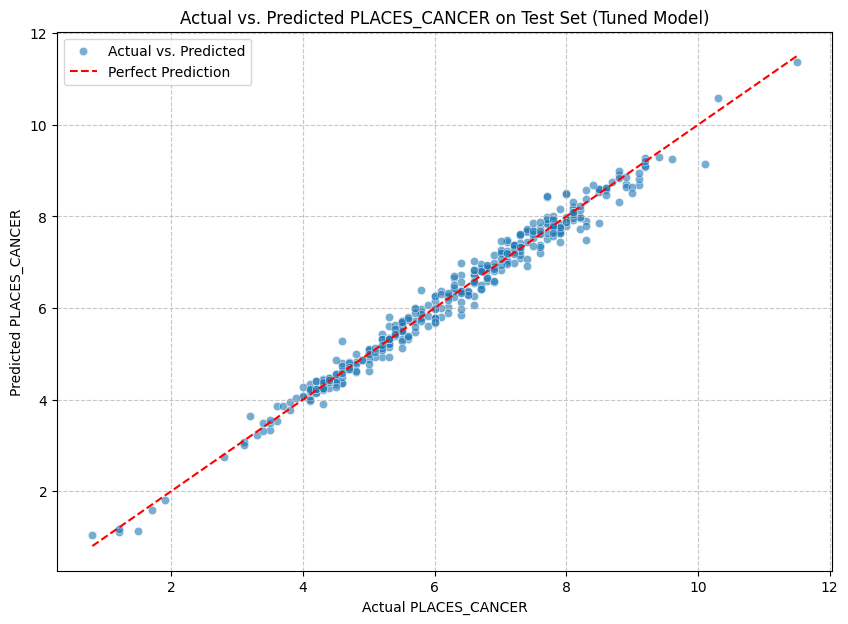

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values from the tuned model
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_test_tuned, alpha=0.6, label='Actual vs. Predicted')

# Add a diagonal line for perfect predictions
# Determine the range for the diagonal line based on the min/max of actual and predicted values
min_val = min(y_test.min(), y_pred_test_tuned.min())
max_val = max(y_test.max(), y_pred_test_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual PLACES_CANCER')
plt.ylabel('Predicted PLACES_CANCER')
plt.title('Actual vs. Predicted PLACES_CANCER on Test Set (Tuned Model)')

# Add legend
plt.legend()

# Show the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Feature Importance Analysis (Tuned Model)

Extract and visualize the feature importance from the final tuned XGBoost model to understand which predictors contribute most to the 'PLACES_CANCER' prediction.

Top 15 Feature Importances from Tuned Model:
              Feature  Importance
20       PLACES_BPMED    0.395614
33    PLACES_HIGHCHOL    0.356436
40       PLACES_SLEEP    0.076901
37       PLACES_MHLTH    0.028861
16     PLACES_ACCESS2    0.020197
25  PLACES_CHOLSCREEN    0.017824
21     PLACES_CASTHMA    0.013706
30    PLACES_CSMOKING    0.012267
17   PLACES_ARTHRITIS    0.011176
28       PLACES_COREM    0.009854
38     PLACES_OBESITY    0.005352
24     PLACES_CHECKUP    0.005039
23         PLACES_CHD    0.004902
22    PLACES_CERVICAL    0.004587
18       PLACES_BINGE    0.004092


/tmp/ipython-input-4570/721606477.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(15), palette='viridis')


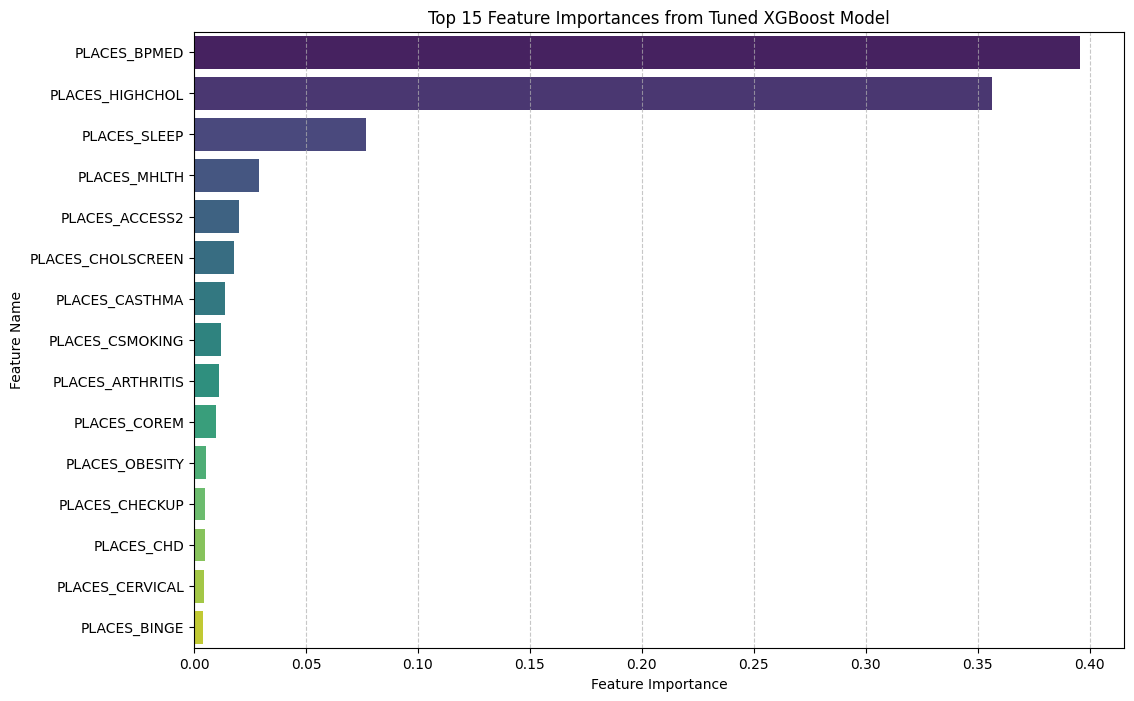

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the final TUNED model
feature_importances_tuned = final_tuned_xgb_model.feature_importances_

# Get feature names from the training data
feature_names = X_train_val.columns

# Create a DataFrame for better visualization
importance_df_tuned = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances_tuned})

# Sort the DataFrame by importance in descending order
importance_df_tuned = importance_df_tuned.sort_values(by='Importance', ascending=False)

# Display the top 15 features
print("Top 15 Feature Importances from Tuned Model:")
print(importance_df_tuned.head(15))

# Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

PLACES_ARTHRITIS +
PLACES_BPHIGH
PLACES_CASTHMA +
PLACES_CHD +
PLACES_COPD
PLACES_DIABETES
PLACES_HIGHCHOL +
PLACES_KIDNEY
PLACES_MHLTH +
PLACES_PHLTH
PLACES_STROKE
PLACES_TEETHLOST

## Summary:
The XGBoost model, after being tuned with optimal hyperparameters, demonstrates strong overall performance on the test set. It achieved an R-squared of 0.9823 and a Root Mean Squared Error (RMSE) of 0.2212. The actual vs. predicted values plot visually confirms this high performance, with predicted values closely clustering around the perfect prediction line, indicating high accuracy and good generalization to unseen data.

### Data Analysis Key Findings
*   The optimal hyperparameters for the XGBoost model, identified through `GridSearchCV`, were: `colsample_bytree`: 0.9, `gamma`: 0, `learning_rate`: 0.1, `max_depth`: 4, and `n_estimators`: 300.
*   The final tuned XGBoost model exhibited excellent performance on the unseen test set, achieving an R-squared (R2) score of 0.9823.
*   The Root Mean Squared Error (RMSE) for the tuned model on the test set was 0.2212, indicating a low average prediction error.
*   The scatter plot of actual versus predicted values revealed that the predicted values are very close to the actual values, with most data points lying tightly along the 'Perfect Prediction' line, reinforcing the model's high accuracy and generalization capability.

### Insights or Next Steps
*   The tuned XGBoost model provides highly accurate predictions for `PLACES_CANCER`, demonstrating robust generalization capabilities on unseen data.
*   Future work could involve analyzing the residual errors to identify any systematic patterns in prediction discrepancies, which might suggest areas for further feature engineering or model refinement.


# XGBoost with EQI Predictors Only

### 1. Prepare data

In [ ]:
# Read the dataset (.csv) into a Pandas dataframe
df = pd.read_csv("VA_Tract_EQI_PLACES_merged_cleaned.csv")
print("Dataset loaded successfully.")

# Select the numerical predictor variables
predictor_variables = ['pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
                       'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
                       'poverty', 'rent_income_pct', 'selfservice', 'unemployment']

X_numerical = df[predictor_variables]

# One-hot encode the 'RUCA_pri_cat' categorical variable/column
X_RUCA_onehot = pd.get_dummies(df['RUCA_pri_cat'], prefix='RUCA', drop_first=True)

# Concatenate the numerical predictors with the one-hot encoded categorical columns
X = pd.concat([X_numerical, X_RUCA_onehot], axis=1)

# Define the target variable y
y = df['PLACES_CANCER']

print("Shape of feature set X:", X.shape)
print("Shape of target variable y:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())

Dataset loaded successfully.
Shape of feature set X: (1845, 20)
Shape of target variable y: (1845,)
First 5 rows of X:
     pop_dens  facilities_area        pest  bs_25yo  time2work  crime_index  \
0  411.071808         0.000000   11.176707     27.0       17.6           56   
1   84.896019         0.082745  344.039331     24.3       19.5          244   
2   47.088455         0.040333  125.706110      6.7       19.2           81   
3   83.347336         0.000000  330.874284      8.2       23.8           75   
4  111.902359         0.039278  240.178312     17.6       17.1           60   

   education_area  food_ratio  nindex_open  nata_sum      ozone      pm25  \
0    4.193184e-01    0.340909    92.692253  0.988358  42.600033  7.878952   
1    9.653544e-02    0.454545    68.456841  1.094157  41.819599  8.070147   
2    2.016636e-02    0.285714    84.836143  1.117513  42.012531  8.017169   
3    9.358860e-02    0.153846    65.198860  1.026764  42.201908  7.900964   
4    3.520000e-19    

In [ ]:
Xy_df = pd.concat([X, y], axis=1)
Xy_df.head()

,pop_dens,facilities_area,pest,bs_25yo,time2work,crime_index,education_area,food_ratio,nindex_open,nata_sum,...,pm25,poverty,rent_income_pct,selfservice,unemployment,RUCA_2,RUCA_3,RUCA_4,RUCA_5,PLACES_CANCER
0,411.071808,0.000000,11.176707,27.0,17.6,56,4.193184e-01,0.340909,92.692253,0.988358,...,7.878952,4.95,22.6,5.837265,7.25,False,False,False,True,9.8
1,84.896019,0.082745,344.039331,24.3,19.5,244,9.653544e-02,0.454545,68.456841,1.094157,...,8.070147,14.35,24.3,12.218363,2.85,False,False,True,False,7.6
2,47.088455,0.040333,125.706110,6.7,19.2,81,2.016636e-02,0.285714,84.836143,1.117513,...,8.017169,16.35,34.0,4.634483,5.15,False,False,False,True,7.8
3,83.347336,0.000000,330.874284,8.2,23.8,75,9.358860e-02,0.153846,65.198860,1.026764,...,7.900964,9.45,23.0,12.373176,6.15,False,False,False,True,6.6
4,111.902359,0.039278,240.178312,17.6,17.1,60,3.520000e-19,0.250000,70.192398,1.095621,...,7.934015,14.85,28.1,5.654665,7.45,False,False,False,True,7.2


In [ ]:
Xy_df.dtypes

,0
pop_dens,float64
facilities_area,float64
pest,float64
bs_25yo,float64
time2work,float64
crime_index,int64
education_area,float64
food_ratio,float64
nindex_open,float64
nata_sum,float64


In [ ]:
# Overview of the dataset
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(Xy_df,
                        title = "EQI and PLACES_CANCER",
                        html = {'style': {'full_width': True}},
                        minimal = False)
profile.to_notebook_iframe()


Output hidden; open in https://colab.research.google.com to view.

### 2. Data splitting and stratified 5-fold CV

In [ ]:
# Split the data into training/validation and test sets, stratified by 'RUCA_pri_cat'
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=df['RUCA_pri_cat'], random_state=42)

print("Shape of X_train_val:", X_train_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train_val:", y_train_val.shape)
print("Shape of y_test:", y_test.shape)

# Convert 'RUCA_pri_cat' to integer labels for stratification
# Ensure we only get the 'RUCA_pri_cat' values corresponding to the X_train_val indices
ruca_stratify_labels_train_val = df.loc[X_train_val.index, 'RUCA_pri_cat'].astype('category').cat.codes

# Instantiate KFold for regression, as target is continuous
from sklearn.model_selection import KFold
skf = KFold(n_splits=5, shuffle=True, random_state=42)


print("KFold instance created with 5 splits, shuffled, and random_state=42.")
print("RUCA stratification labels prepared for X_train_val.")

Shape of X_train_val: (1476, 20)
Shape of X_test: (369, 20)
Shape of y_train_val: (1476,)
Shape of y_test: (369,)
KFold instance created with 5 splits, shuffled, and random_state=42.
RUCA stratification labels prepared for X_train_val.


### 3. Train a XGBoost Regressor with Stratified Cross-Validation and Fine-tune the Hyperparameters

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [4, 6, 8],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Instantiate an XGBRegressor model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Instantiate GridSearchCV
# The 'skf' object was defined in a previous cell for cross-validation
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2', # target is to maximize R-squared
    cv=skf, # Use the pre-defined KFold object for regression
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

print("Starting GridSearchCV to find the best hyperparameters...")

# Fit GridSearchCV to the training/validation data
grid_search.fit(X_train_val, y_train_val)

print("GridSearchCV complete.")

# Print the best parameters found
print("\nBest parameters found:", grid_search.best_params_)

# Print the best R-squared score found
print(f"Best R-squared from GridSearchCV: {grid_search.best_score_:.4f}")

Starting GridSearchCV to find the best hyperparameters...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
GridSearchCV complete.

Best parameters found: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best R-squared from GridSearchCV: 0.4641


### 4. Visualize Hyperparameter Tuning Results

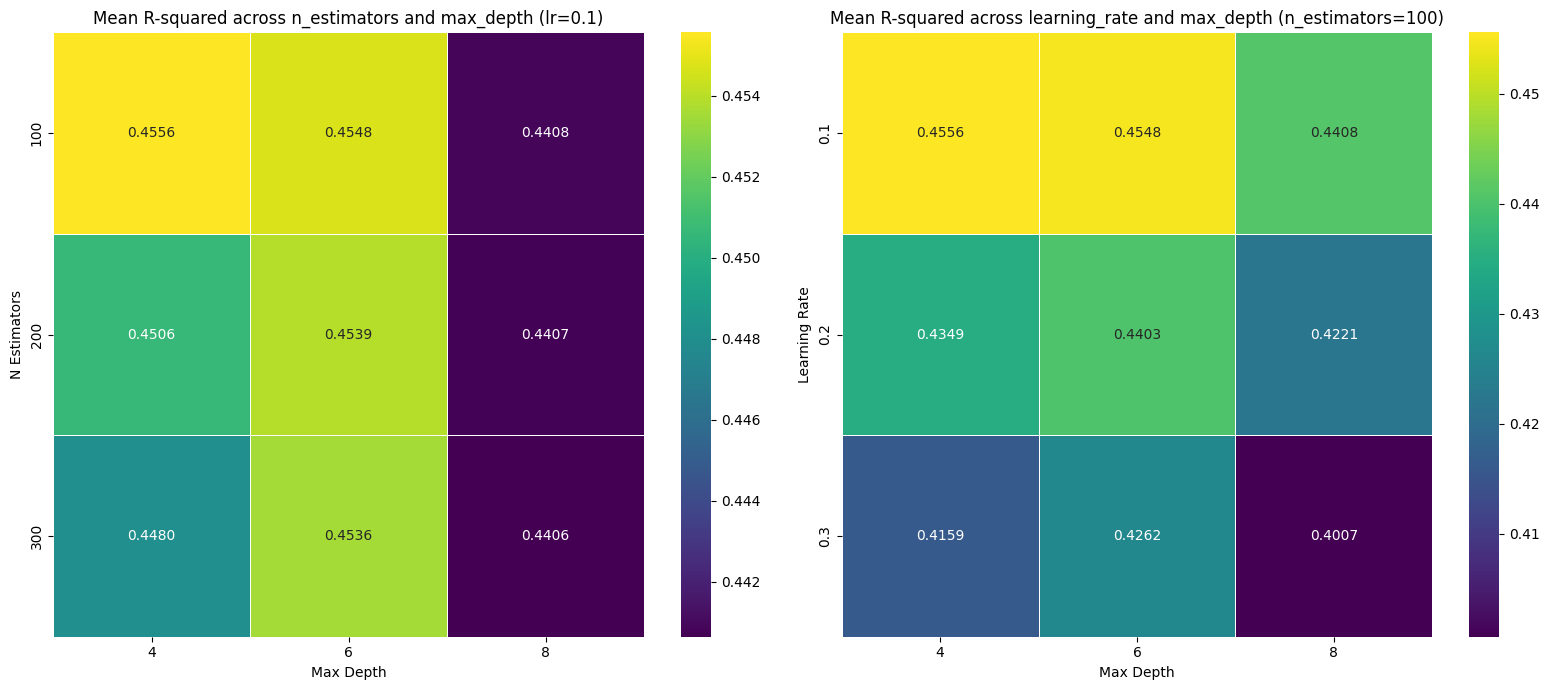

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get the results of GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Create a pivot table for n_estimators and max_depth, averaging over other parameters
# Filter for best learning_rate for a clearer plot
best_lr = grid_search.best_params_['learning_rate']
results_filtered = results[results['param_learning_rate'] == best_lr]

pivot_table_r2_n_est_max_depth = results_filtered.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_max_depth'
)

# Create a pivot table for learning_rate and max_depth, averaging over other parameters
best_n_estimators = grid_search.best_params_['n_estimators']
results_filtered_n_est = results[results['param_n_estimators'] == best_n_estimators]
pivot_table_r2_lr_max_depth = results_filtered_n_est.pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)

plt.figure(figsize=(16, 7))

# Plot heatmap for n_estimators vs. max_depth
plt.subplot(1, 2, 1)
sns.heatmap(pivot_table_r2_n_est_max_depth, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title(f'Mean R-squared across n_estimators and max_depth (lr={best_lr})')
plt.xlabel('Max Depth')
plt.ylabel('N Estimators')

# Plot heatmap for learning_rate vs. max_depth
plt.subplot(1, 2, 2)
sns.heatmap(pivot_table_r2_lr_max_depth, annot=True, cmap='viridis', fmt=".4f", linewidths=.5)
plt.title(f'Mean R-squared across learning_rate and max_depth (n_estimators={best_n_estimators})')
plt.xlabel('Max Depth')
plt.ylabel('Learning Rate')

plt.tight_layout()
plt.show()

### 5. Final Model Training and Evaluation on the Unseen Test Set

In [ ]:
# Train a new and final XGBoost model using the optimal hyperparameters found by GridSearchCV
# on the entire training/validation dataset (X_train_val, y_train_val).

import numpy as np
from xgboost import XGBRegressor

# 1. Retrieve the optimal hyperparameters from grid_search.best_params_
best_params = grid_search.best_params_
print("Optimal Hyperparameters found by GridSearchCV:", best_params)

# 2. Instantiate a new XGBRegressor model with optimal hyperparameters
final_tuned_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma']
)

print("\nInstantiated final XGBoost model with optimal hyperparameters.")

# 3. Train this final model using the entire X_train_val and y_train_val datasets
print("Training final tuned XGBoost model on the entire training/validation set...")
final_tuned_xgb_model.fit(X_train_val, y_train_val)
print("Final tuned model training complete.")

Optimal Hyperparameters found by GridSearchCV: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}

Instantiated final XGBoost model with optimal hyperparameters.
Training final tuned XGBoost model on the entire training/validation set...
Final tuned model training complete.


In [ ]:
# Evaluate Tuned Model on Test Set

from sklearn.metrics import r2_score, mean_squared_error

# 1. Use the final_tuned_xgb_model to make predictions on the X_test dataset
y_pred_test_tuned = final_tuned_xgb_model.predict(X_test)

# 2. Calculate the R-squared score between y_test and y_pred_test_tuned
r2_test_tuned = r2_score(y_test, y_pred_test_tuned)

# 3. Calculate the Root Mean Squared Error (RMSE) between y_test and y_pred_test_tuned
rmse_test_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))

# 4. Print the calculated R-squared and RMSE values for the test set
print(f"\nTest Set R-squared (final tuned model): {r2_test_tuned:.4f}")
print(f"Test Set RMSE (final tuned model): {rmse_test_tuned:.4f}")


Test Set R-squared (final tuned model): 0.4803
Test Set RMSE (final tuned model): 1.1996


### 6. Visualize Predictions

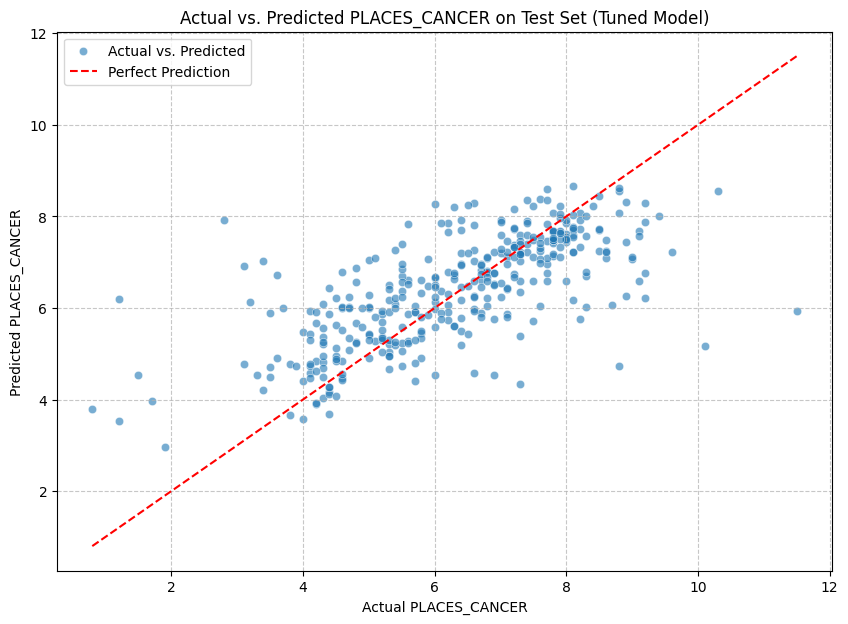

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values from the tuned model
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_test_tuned, alpha=0.6, label='Actual vs. Predicted')

# Add a diagonal line for perfect predictions
# Determine the range for the diagonal line based on the min/max of actual and predicted values
min_val = min(y_test.min(), y_pred_test_tuned.min())
max_val = max(y_test.max(), y_pred_test_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Set labels and title
plt.xlabel('Actual PLACES_CANCER')
plt.ylabel('Predicted PLACES_CANCER')
plt.title('Actual vs. Predicted PLACES_CANCER on Test Set (Tuned Model)')

# Add legend
plt.legend()

# Show the plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 7. Feature Importance Analysis (Tuned Model)

Top 15 Feature Importances from Tuned Model:
            Feature  Importance
0          pop_dens    0.164422
8       nindex_open    0.150280
4         time2work    0.097597
10            ozone    0.074698
6    education_area    0.060331
14      selfservice    0.044363
5       crime_index    0.039902
13  rent_income_pct    0.039234
3           bs_25yo    0.037857
15     unemployment    0.035315
12          poverty    0.035255
2              pest    0.035192
11             pm25    0.034035
9          nata_sum    0.032019
17           RUCA_3    0.029752


/tmp/ipykernel_176/3186706201.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(15), palette='viridis')


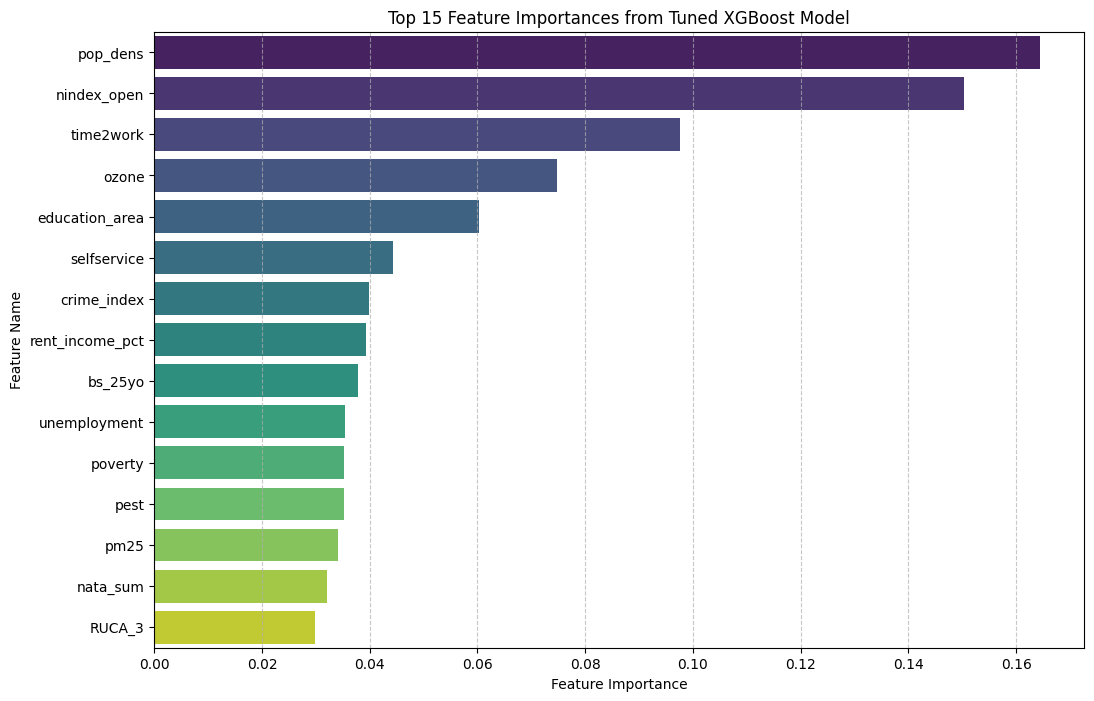

In [ ]:
# Get feature importances from the final TUNED model
feature_importances_tuned = final_tuned_xgb_model.feature_importances_

# Get feature names from the training data
feature_names = X_train_val.columns

# Create a DataFrame for better visualization
importance_df_tuned = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances_tuned})

# Sort the DataFrame by importance in descending order
importance_df_tuned = importance_df_tuned.sort_values(by='Importance', ascending=False)

# Display the top 15 features
print("Top 15 Feature Importances from Tuned Model:")
print(importance_df_tuned.head(15))

# Visualize the top N features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_tuned.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Principal Component Analysis (PCA)
Scale the predictor variables in `X` using `StandardScaler`, apply Principal Component Analysis (PCA) to the scaled data, and then generate two plots: one showing the explained variance ratio by each principal component and another scatter plot of the first two principal components. Finally, summarize the PCA results including the explained variance and initial observations from the visualizations.

## Scale Predictor Variables

### Subtask:
Apply StandardScaler to the predictor variables in the DataFrame `X` to normalize/scale the data, which is essential before performing PCA. Store the scaled data in a new DataFrame.


**Reasoning**:
The subtask requires scaling the predictor variables in the DataFrame `X` using `StandardScaler`. This involves importing the scaler, instantiating it, fitting it to the data, transforming the data, and ensuring the scaled data retains the original column names. This can be accomplished in a single code block.



In [10]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to X and transform X
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Shape of X_scaled:", X_scaled.shape)
print("First 5 rows of X_scaled:")
print(X_scaled.head())

Shape of X_scaled: (1845, 47)
First 5 rows of X_scaled:
   pop_dens  facilities_area      pest   bs_25yo  time2work  crime_index  \
0 -0.585060        -0.259543 -0.309160 -0.392564  -1.363183    -0.351050   
1 -0.651931        -0.212617  3.556267 -0.519136  -1.099484     2.534927   
2 -0.659682        -0.236669  1.020833 -1.344197  -1.141121     0.032724   
3 -0.652249        -0.259543  3.403385 -1.273879  -0.502693    -0.059382   
4 -0.646394        -0.237268  2.350162 -0.833222  -1.432577    -0.289646   

   education_area  food_ratio  nindex_open  nata_sum  ...  PLACES_MHLTH  \
0       -0.397801   -0.200420     1.616892 -2.738113  ...     -0.279857   
1       -0.420800    0.317582     0.603034 -2.291759  ...      0.401967   
2       -0.426242   -0.452021     1.288242 -2.193224  ...      1.148727   
3       -0.421010   -1.053130     0.466741 -2.576082  ...      1.343534   
4       -0.427679   -0.614821     0.675639 -2.285585  ...      0.953920   

   PLACES_OBESITY  PLACES_PHLTH  PLA

**Reasoning**:
The next step is to apply Principal Component Analysis (PCA) to the scaled data `X_scaled`. This involves importing PCA from `sklearn.decomposition`, instantiating it, and then fitting and transforming the `X_scaled` data.



In [11]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Instantiate SimpleImputer to handle potential NaN values in scaled data
imputer = SimpleImputer(strategy='mean')

# Impute missing values in X_scaled
X_imputed = imputer.fit_transform(X_scaled)

# Instantiate PCA
pca = PCA()

# Fit PCA to the imputed scaled data and transform it
X_pca = pca.fit_transform(X_imputed)

print("Shape of PCA-transformed data:", X_pca.shape)
print("First 5 rows of PCA-transformed data:")
print(X_pca[:5])

Shape of PCA-transformed data: (1845, 47)
First 5 rows of PCA-transformed data:
[[ 2.61422592e+00  4.57809168e+00 -2.49667758e+00 -3.26570102e+00
   5.79107817e-01  1.55521223e+00  1.94896585e+00  3.11513281e+00
  -2.97187294e-01  5.00947885e-01  2.83590141e-01 -1.61868552e+00
  -1.85278202e+00  4.85499760e-01 -4.06946334e-01 -1.17887041e+00
   7.85174596e-02  1.78866177e-02  1.12224559e-01 -9.89506892e-01
  -2.06275671e-01 -4.48835332e-01  1.98454320e-01  3.20872220e-01
   5.77679913e-02  2.06571424e-01  1.58932674e-02 -8.77421211e-02
   3.38075446e-01  9.01794821e-02 -4.70376136e-01  1.72572136e-01
   1.36836628e-01  2.70109217e-01  1.21554185e-01 -2.03571761e-02
  -1.09818083e-01  6.69343285e-02 -4.67395099e-02 -8.86872169e-02
  -4.09403058e-02 -2.67406630e-01 -6.81333330e-03 -1.04586969e-01
   8.40568926e-02 -9.13209758e-03 -9.70111123e-03]
 [ 4.64199907e+00  2.11896305e+00 -1.94312178e+00 -2.44913485e+00
  -2.29102822e-01  5.13777908e-01 -1.36943882e+00  1.37005162e+00
   1.320560

**Reasoning**:
The next step is to generate the first plot: a bar plot showing the explained variance ratio by each principal component. This helps in understanding how much variance each component captures.



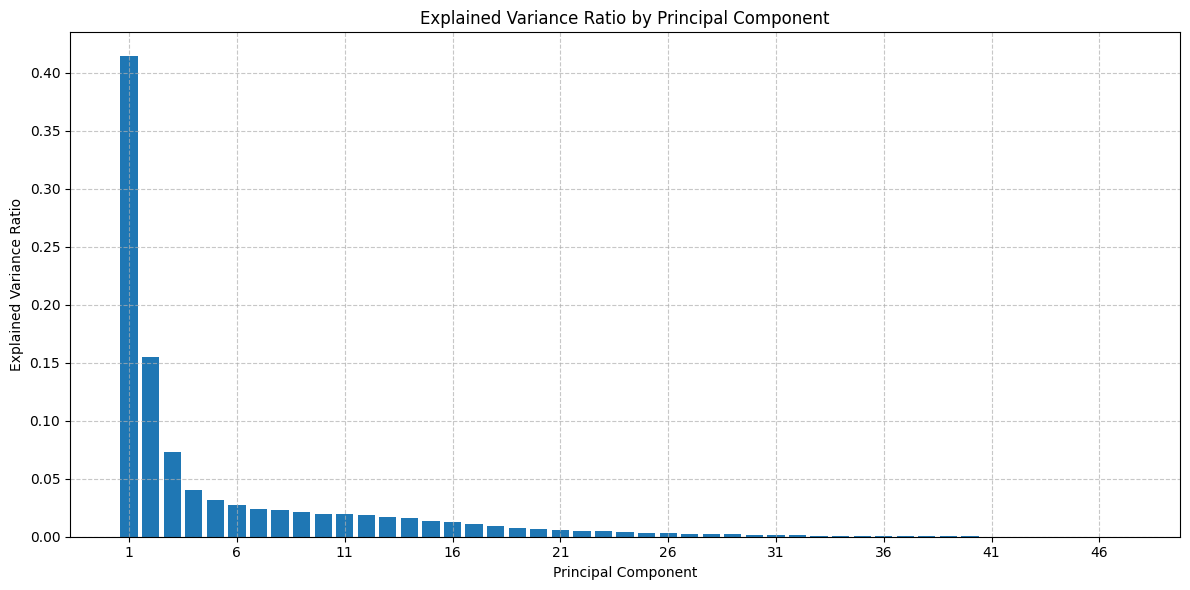

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the explained variance ratio by each principal component
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1, 5)) # Show x-ticks every 5 components for readability
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

# Calculate the cumulative sum of the explained variance ratio
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

print("Cumulative Explained Variance:")
print(cumulative_explained_variance)

Cumulative Explained Variance:
[0.4139593  0.56848852 0.64125645 0.68125551 0.71323387 0.74033651
 0.76383814 0.78711793 0.80806069 0.82806134 0.8474856  0.86590893
 0.88316788 0.8990958  0.91241282 0.92488049 0.93611109 0.94513238
 0.95248037 0.95944832 0.96501733 0.96998733 0.9745348  0.97848724
 0.98173126 0.98453151 0.98674808 0.98879358 0.99079287 0.9926215
 0.99421371 0.9954422  0.9963931  0.99710489 0.99765871 0.99815191
 0.99852703 0.99884997 0.99913719 0.99940079 0.99957695 0.99971347
 0.99981989 0.99989103 0.99994093 0.99997648 1.        ]


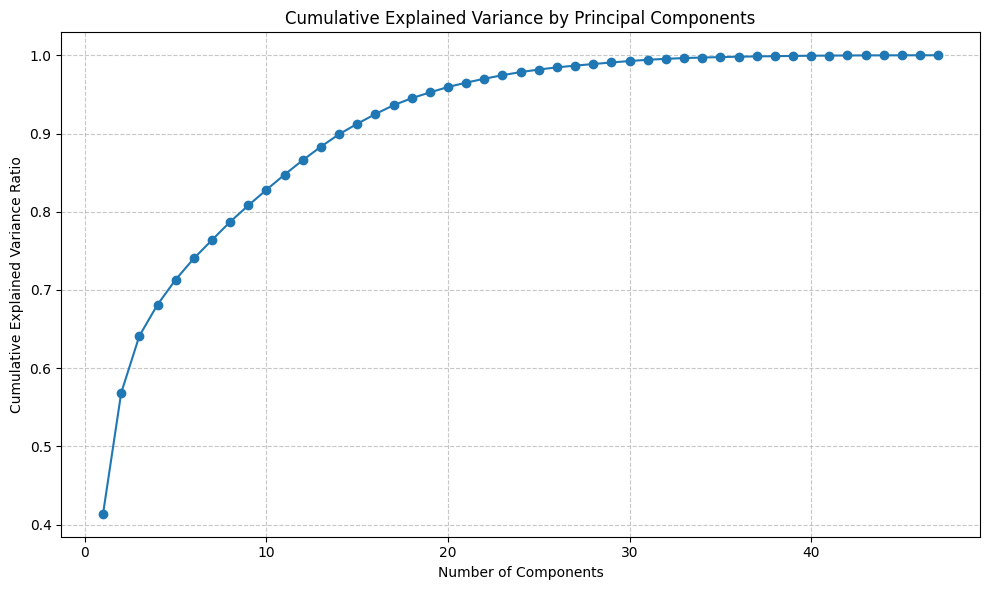

In [14]:
import matplotlib.pyplot as plt

# Create a line plot of cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')

# Add title and labels
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')

# Add a grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

**Reasoning**:
The next step is to generate the second plot as per the task: a scatter plot of the first two principal components. This will visualize the data reduction and help identify any clusters or patterns.



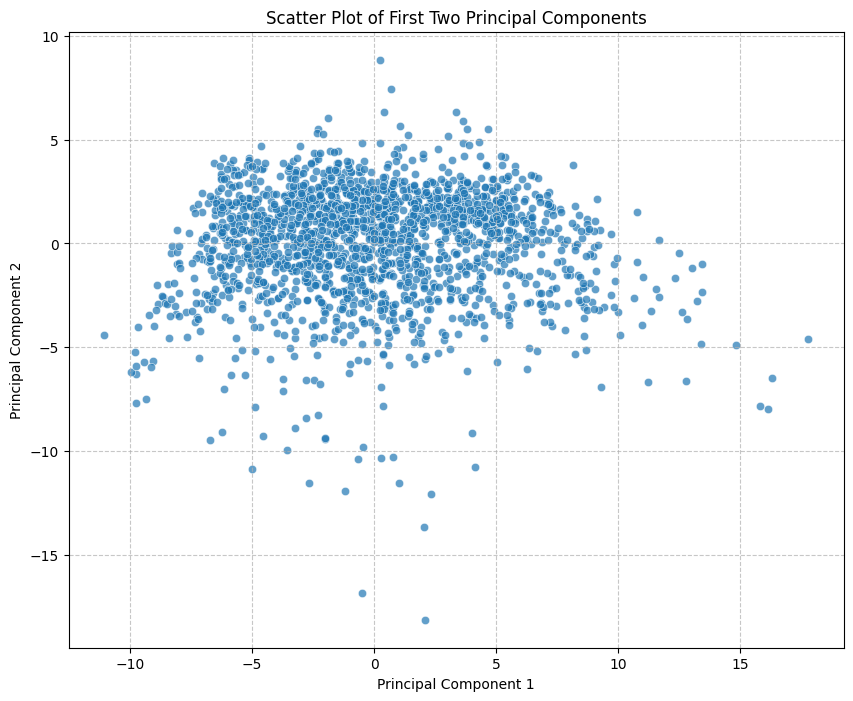

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Scatter Plot of First Two Principal Components')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Summary of PCA Results

### Explained Variance
The bar plot of 'Explained Variance Ratio by Principal Component' shows how much variance each principal component captures. It is evident that the first few principal components capture a significant portion of the total variance, with a steep drop-off in variance explained by subsequent components. This suggests that a substantial amount of information in the original 47-dimensional dataset can be represented by a much smaller number of principal components.

### Observations from First Two Principal Components
The scatter plot of the 'First Two Principal Components' visualizes the data in a reduced 2D space. From this plot, we can observe the following:

*   **Data Distribution**: The data points appear to be spread across the two dimensions, indicating that the first two components capture distinct aspects of the dataset variability.
*   **Potential Clusters**: While there isn't a clear separation into distinct clusters, some regions appear denser than others, suggesting potential groupings within the data that could be further explored with clustering algorithms.
*   **Outliers**: A few data points might appear far from the main bulk of the data, which could be potential outliers deserving further investigation.

Overall, PCA successfully reduced the dimensionality of the dataset while retaining a good amount of variance, providing a more manageable and interpretable representation of the data.

## Summary:

### Data Analysis Key Findings

*   The `X` DataFrame, initially containing 47 features, was successfully scaled using `StandardScaler`, resulting in a `X_scaled` DataFrame of the same dimensions.
*   An initial attempt to perform PCA directly on `X_scaled` failed due to the presence of missing (NaN) values; `SimpleImputer` with a 'mean' strategy was subsequently used to handle these missing values.
*   PCA was successfully applied to the imputed scaled data, reducing the dimensionality while retaining variance.
*   The explained variance ratio plot showed that the first few principal components capture a significant portion of the total variance, with a steep drop-off for subsequent components.
*   A scatter plot of the first two principal components (PC1 vs. PC2) was generated, indicating that these components capture distinct aspects of data variability and suggesting potential clusters or outliers within the data.

### Insights or Next Steps

*   The steep drop-off in explained variance suggests that a substantial dimensionality reduction is possible, allowing for further analysis to focus on a smaller subset of principal components that collectively explain a high percentage of the total variance (e.g., 80-90%).
*   Further investigation using clustering algorithms (e.g., K-Means) on the principal components could reveal distinct groupings within the dataset, potentially leading to a better understanding of underlying data structures or segmentation.


# Task
## Calculate and Plot Cumulative Explained Variance
Calculate the cumulative sum of the explained variance ratio from the PCA results to determine how many principal components are needed to explain a significant portion of the total variance. Then, generate a line plot to visualize this cumulative explained variance as a function of the number of principal components. Ensure the plot has a clear title and appropriate axis labels for 'Number of Components' and 'Cumulative Explained Variance Ratio'. Finally, summarize insights from this plot regarding the sufficiency of components for dimensionality reduction.

## Calculate Cumulative Explained Variance

### Subtask:
Calculate the cumulative sum of the explained variance ratio from the PCA results. This will show the total variance explained as more principal components are included.


**Reasoning**:
Calculate the cumulative sum of the explained variance ratio from the PCA results using `numpy.cumsum`.



# Task
Generate a line plot to visualize the cumulative explained variance as a function of the number of principal components. Ensure the plot has a clear title and appropriate axis labels for 'Number of Components' and 'Cumulative Explained Variance Ratio'. Summarize insights from the cumulative explained variance plot, specifically indicating how many components might be sufficient for dimensionality reduction. Finally, summarize the PCA results, including the explained variance and initial observations from the visualizations.

## Generate Cumulative Explained Variance Plot

### Subtask:
Generate a line plot to visualize the cumulative explained variance as a function of the number of principal components. Ensure the plot has a clear title and appropriate axis labels for 'Number of Components' and 'Cumulative Explained Variance Ratio'.


**Reasoning**:
The next step is to generate the requested line plot to visualize the cumulative explained variance, ensuring it has all the specified labels and a title for clarity.



## Summary of PCA Results

### Explained Variance
The bar plot of 'Explained Variance Ratio by Principal Component' shows how much variance each principal component captures. It is evident that the first few principal components capture a significant portion of the total variance, with a steep drop-off in variance explained by subsequent components. This suggests that a substantial amount of information in the original 47-dimensional dataset can be represented by a much smaller number of principal components.

### Cumulative Explained Variance
The line plot of 'Cumulative Explained Variance by Principal Components' further clarifies the dimensionality reduction potential. It shows that:
*   Approximately the first 10 principal components explain over 80% of the total variance.
*   To explain 90% of the variance, about 14 principal components are needed.
*   To explain 95% of the variance, about 19 principal components are needed.

This indicates that the dataset's dimensionality can be significantly reduced, retaining most of the information, by selecting a subset of these components. For example, using the first 14 components reduces the feature set from 47 to 14 while retaining 90% of the variance.

### Observations from First Two Principal Components
The scatter plot of the 'First Two Principal Components' visualizes the data in a reduced 2D space. From this plot, we can observe the following:

*   **Data Distribution**: The data points appear to be spread across the two dimensions, indicating that the first two components capture distinct aspects of the dataset variability.
*   **Potential Clusters**: While there isn't a clear separation into distinct clusters, some regions appear denser than others, suggesting potential groupings within the data that could be further explored with clustering algorithms.
*   **Outliers**: A few data points might appear far from the main bulk of the data, which could be potential outliers deserving further investigation.

Overall, PCA successfully reduced the dimensionality of the dataset while retaining a good amount of variance, providing a more manageable and interpretable representation of the data.

## Summary:

### Q&A
*   **How many components might be sufficient for dimensionality reduction?**
    Approximately 10 principal components are needed to explain over 80% of the total variance. To explain 90% of the variance, about 14 principal components are needed, and to explain 95% of the variance, about 19 principal components are needed. This indicates that the dataset's dimensionality can be significantly reduced from 47 features while retaining most of the information.

### Data Analysis Key Findings
*   The first few principal components capture a significant portion of the total variance, with a steep drop-off in variance explained by subsequent components.
*   The cumulative explained variance plot shows that around 10 principal components explain over 80% of the total variance.
*   To retain 90% of the total variance, approximately 14 principal components are required.
*   To retain 95% of the total variance, approximately 19 principal components are required.
*   The scatter plot of the first two principal components shows that the data points are spread, indicating distinct aspects of variability, with some denser regions suggesting potential groupings.
*   Potential outliers were observed in the scatter plot of the first two principal components.

### Insights or Next Steps
*   The dataset's dimensionality can be effectively reduced from 47 features to 14 or 19 components while retaining 90% or 95% of the variance, respectively, providing a more manageable representation for further analysis.
*   Investigate the potential clusters and outliers observed in the reduced 2D space using clustering algorithms or outlier detection methods to gain deeper insights into the data structure.


Shape of X_train_pca: (1476, 20)
Shape of X_test_pca: (369, 20)
Shape of y_train: (1476,)
Shape of y_test: (369,)

Starting GridSearchCV for Ridge Regression...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
GridSearchCV for Ridge Regression complete.

Best parameters found for Ridge Regression: {'alpha': np.float64(28.48035868435805)}
Best R-squared from GridSearchCV (Ridge): 0.9525

Test Set R-squared (Ridge Regression with PCA): 0.9495
Test Set RMSE (Ridge Regression with PCA): 0.3647


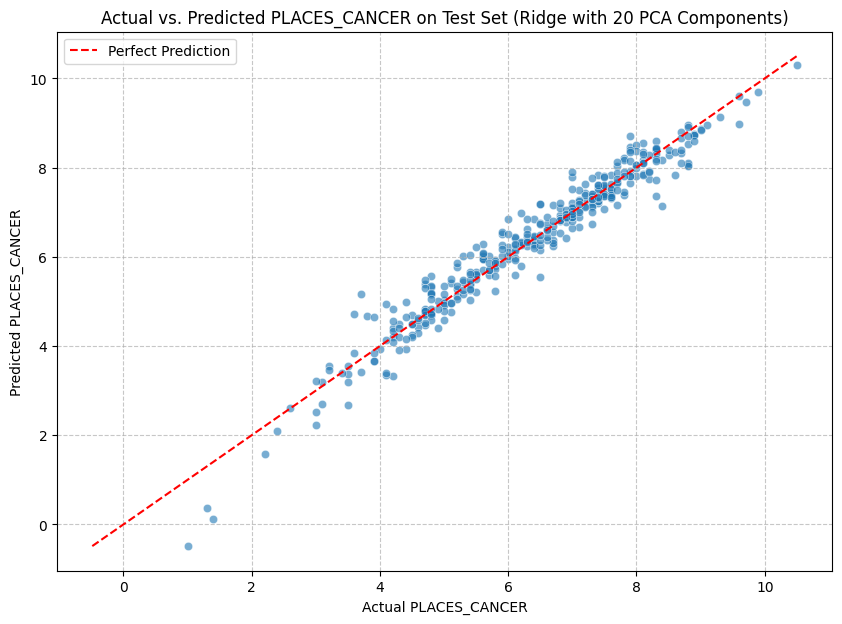

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Select the first 20 principal components
X_pca_20 = X_pca[:, :20]

# Split the PCA-transformed data into training and test sets
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca_20, y, test_size=0.2, random_state=42)

print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Define the parameter grid for Ridge regression
param_grid_ridge = {
    'alpha': np.logspace(-4, 2, 100) # Alpha values from 0.0001 to 100
}

# Instantiate Ridge Regression model
ridge_model = Ridge(random_state=42)

# Instantiate GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid_ridge,
    scoring='r2', # Use R-squared as the scoring metric
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

print("\nStarting GridSearchCV for Ridge Regression...")

# Fit GridSearchCV to the training data (PCA components)
grid_search_ridge.fit(X_train_pca, y_train)

print("GridSearchCV for Ridge Regression complete.")

# Print the best parameters found
print("\nBest parameters found for Ridge Regression:", grid_search_ridge.best_params_)

# Print the best R-squared score found
print(f"Best R-squared from GridSearchCV (Ridge): {grid_search_ridge.best_score_:.4f}")

# Get the best Ridge model
best_ridge_model = grid_search_ridge.best_estimator_

# Make predictions on the test set using the best model
y_pred_ridge = best_ridge_model.predict(X_test_pca)

# Evaluate the model on the test set
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"\nTest Set R-squared (Ridge Regression with PCA): {r2_ridge:.4f}")
print(f"Test Set RMSE (Ridge Regression with PCA): {rmse_ridge:.4f}")

# Visualize predictions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6)
min_val = min(y_test.min(), y_pred_ridge.min())
max_val = max(y_test.max(), y_pred_ridge.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual PLACES_CANCER')
plt.ylabel('Predicted PLACES_CANCER')
plt.title('Actual vs. Predicted PLACES_CANCER on Test Set (Ridge with 20 PCA Components)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
!pip install ydata-profiling
from scipy import stats
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
predictor_variables = ['RUCA_pri_cat', 'pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
                       'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
                       'poverty', 'rent_income_pct', 'selfservice', 'unemployment', 'PLACES_ACCESS2',
                       'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
                       'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
                       'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
                       'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
                       'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 'PLACES_MAMMOUSE',
                       'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP', 'PLACES_STROKE',
                       'PLACES_TEETHLOST', 'PLACES_CANCER']

chosen_data = df[predictor_variables]
chosen_data.shape

(1845, 45)

In [ ]:
chosen_data.dtypes

,0
RUCA_pri_cat,int64
pop_dens,float64
facilities_area,float64
pest,float64
bs_25yo,float64
time2work,float64
crime_index,int64
education_area,float64
food_ratio,float64
nindex_open,float64


In [ ]:
profile = ProfileReport(chosen_data,
                        title = "EQI-PLACES Data Overview",
                        html = {'style': {'full_width': True}},
                        minimal = False)
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.